In [2]:
import psi4
import numpy as np
import matplotlib.pyplot as plt

# Calculating Spectroscopic Constants from a Potential Energy Surface

Adapted from "Calculating Spectroscopic Constants from a Potential Energy Surface" written by Dr Ashler Ringer McDonald and Dr Dominic A. Sirianni.

The spectroscopic constants for a diatomic molecule can be calculated from a series of potential energies computed for different bond separations. In this lab, you will calculate the spectroscopic constants for several diatomic molecules and compare their force constants. You will also study the effect of the harmonic approximation in determining the vibrational energy levels. 


## A. Computing a potential energy surface

So far, we have learned how to calculate spectroscopic constants using data we've collected, in combination with equations from harmonic oscillator and rigid rotator models. We have also used computational tools to calculate rotational $B$ constants using a variety of ab initio methods.

For reasons we will not go in to, computation of vibrational constants from purely theoretical tools can be quite tricky. Rather than finding an analytical solution (like we did for $B$), we can only get an approximate solution using a potential energy surface. On top of that, the potential energy surface we use will not be exact, so we'll need to test out a few methods there as well.

### 1. Getting started with potential energy surfaces

A potential energy surface (PES) is, at its core, a function that maps a set of atomic positions to a potential energy. While these can be rather complicated, we will stick to the simplest 1-dimensional case since we are interested in spectroscopic constants of diatomics.

While we only need about seven points for our vibrational analysis, let's compute and plot a larger surface to see what it looks like.

The below cell has code to define our molecule and interatomic distances (rvals), and it will also run the energies and store them in a list. This molecule is carbon monoxide.

In [4]:
# A template for our molecule
mol_templ = """
#H@2.01410
C
O 1 **R**"""

#The interatomic distances
# Here, linspace will return a list
# of 25 numbers between 0.8 and 2.0, evenly spaced
rvals = np.linspace(0.8,2.0, 25)

# We will store the results here
energies = []

# This loops over each distance and computes the energy
for r in rvals:
    molecule = psi4.geometry(mol_templ.replace("**R**", str(r)))
    # The method is specified here
    energy = psi4.energy("SCF/cc-pVDZ", molecule=molecule)
    energies.append(energy)


Scratch directory: /tmp/

Scratch directory: /tmp/

*** tstart() called on jeffschriber.local
*** at Mon Oct 10 16:05:17 2022

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1 entry C          line   138 file /Users/jeffschriber/src/psi4-debug-install/share/psi4/basis/cc-pvdz.gbs 
    atoms 2 entry O          line   198 file /Users/jeffschriber/src/psi4-debug-install/share/psi4/basis/cc-pvdz.gbs 


         ---------------------------------------------------------
                                   SCF
               by Justin Turney, Rob Parrish, Andy Simmonett
                          and Daniel G. A. Smith
                              RHF Reference
                        1 Threads,    500 MiB Core
         ---------------------------------------------------------

  ==> Geometry <==

    Molecular point group: c2v
    Full point group: C_inf_v

    Geometry (in Angstrom), charge = 0, multiplicity = 1:

       Center              X   

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 1.4425720003E-02.
  Reciprocal condition number of the overlap matrix is 4.5274243590E-03.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 1.7004908061E-02.
  Reciprocal condition number of the overlap matrix is 5.4020942983E-03.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 1.9637299358E-02.
  Reciprocal condition number of the overlap matrix is 6.3384306331E-03.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 2.2330191024E-02.
  Reciprocal condition number of the overlap matrix is 7.3510166307E-03.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 

...

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 4.5120999362E-02.
  Reciprocal condition number of the overlap matrix is 1.7147572459E-02.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 5.3268145146E-02.
  Reciprocal condition number of the overlap matrix is 2.0951312141E-02.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 6.2707466308E-02.
  Reciprocal condition number of the overlap matrix is 2.5545801745E-02.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 7.3199779865E-02.
  Reciprocal condition number of the overlap matrix is 3.0897614583E-02.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 


*** tstop() called on jeffschriber.local at Mon Oct 10 16:05:26 2022
Module time:
	user time   =       0.29 seconds =       0.00 minutes
	system time =       0.03 seconds =       0.00 minutes
	total time  =          1 seconds =       0.02 minutes
Total time:
	user time   =      17.95 seconds =       0.30 minutes
	system time =       1.33 seconds =       0.02 minutes
	total time  =         35 seconds =       0.58 minutes


Let's plot the PES to see what it looks like:

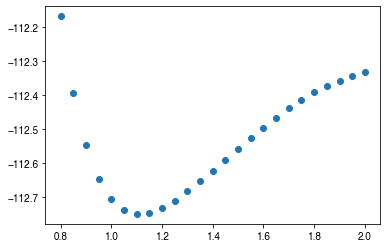

In [5]:
plt.scatter(rvals, energies)

Looking at the plot, we can see that the minimum bond length is around 1.1 angstrom. Let's run a quick computation *at the same level of theory* to verify the bond length. No need to use Avogadro here, we can just provide a reasonable guess input.

In [7]:
diatomic = psi4.geometry("""
C
O 1 1.1
""")

psi4.optimize("SCF/cc-pvdz")


Scratch directory: /tmp/

Scratch directory: /tmp/
gradient() will perform analytic gradient computation.

*** tstart() called on jeffschriber.local
*** at Mon Oct 10 16:19:23 2022

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1 entry C          line   138 file /Users/jeffschriber/src/psi4-debug-install/share/psi4/basis/cc-pvdz.gbs 
    atoms 2 entry O          line   198 file /Users/jeffschriber/src/psi4-debug-install/share/psi4/basis/cc-pvdz.gbs 


         ---------------------------------------------------------
                                   SCF
               by Justin Turney, Rob Parrish, Andy Simmonett
                          and Daniel G. A. Smith
                              RHF Reference
                        1 Threads,    500 MiB Core
         ---------------------------------------------------------

  ==> Geometry <==

    Molecular point group: c2v
    Full point group: C_inf_v

    Geometry (in Angstrom), charge 

    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3


  -Total Gradient:
     Atom            X                  Y                   Z
    ------   -----------------  -----------------  -----------------
       1       -0.000000000000     0.000000000000     0.030459612112
       2        0.000000000000     0.000000000000    -0.030459612112


*** tstop() called on jeffschriber.local at Mon Oct 10 16:19:23 2022
Module time:
	user time   =       0.10 seconds =       0.00 minutes
	system time =       0.03 seconds =       0.00 minutes
	total time  =          0 seconds =       0.00 minutes
Total time:
	user time   =      18.55 seconds =       0.31 minutes
	system time =       1.48 seconds =       0.02 minutes
	total time  =        872 seconds =      14.53 minutes

			-----------------------------------------
			 OPTKING 2.0: for geometry optimizations 
			  - R.A. King,  Bethel Universit

     X:     0.0000      Y:     0.0000      Z:    -0.0559     Total:     0.0559

  Dipole Moment: [D]
     X:     0.0000      Y:     0.0000      Z:    -0.1421     Total:     0.1421


*** tstop() called on jeffschriber.local at Mon Oct 10 16:19:23 2022
Module time:
	user time   =       0.17 seconds =       0.00 minutes
	system time =       0.02 seconds =       0.00 minutes
	total time  =          0 seconds =       0.00 minutes
Total time:
	user time   =      18.73 seconds =       0.31 minutes
	system time =       1.50 seconds =       0.03 minutes
	total time  =        872 seconds =      14.53 minutes

*** tstart() called on jeffschriber.local
*** at Mon Oct 10 16:19:24 2022


         ------------------------------------------------------------
                                   SCF GRAD                          
                          Rob Parrish, Justin Turney,                
                       Andy Simmonett, and Alex Sokolov              
         ----------------------------


*** tstop() called on jeffschriber.local at Mon Oct 10 16:19:24 2022
Module time:
	user time   =       0.17 seconds =       0.00 minutes
	system time =       0.01 seconds =       0.00 minutes
	total time  =          0 seconds =       0.00 minutes
Total time:
	user time   =      19.00 seconds =       0.32 minutes
	system time =       1.52 seconds =       0.03 minutes
	total time  =        873 seconds =      14.55 minutes
Optimizer: Optimization complete!


-112.74990561516827


*** tstart() called on jeffschriber.local
*** at Mon Oct 10 16:19:24 2022


         ------------------------------------------------------------
                                   SCF GRAD                          
                          Rob Parrish, Justin Turney,                
                       Andy Simmonett, and Alex Sokolov              
         ------------------------------------------------------------

  ==> Geometry <==

    Molecular point group: c2v
    Full point group: C_inf_v

    Geometry (in Angstrom), charge = 0, multiplicity = 1:

       Center              X                  Y                   Z               Mass       
    ------------   -----------------  -----------------  -----------------  -----------------
         C            0.000000000000     0.000000000000    -0.634267367930    12.000000000000
         O            0.000000000000     0.000000000000     0.475851768902    15.994914619570

  Nuclear repulsion =   22.880883023625035

  ==> Basi

Looking at the bottom of the file, we can see that our bond length is 1.110 angstrom.

### 2. Using a PES to compute spectroscopic constants

Now, we can use this information to compute many of our spectroscopic constants (again, note any differences between our previous notation and that output here). What we need to do is to provide a set of points and energies centered around the minimum. So, let's compute a smaller part of our potential, store the energies and rvalues, and then call the appropriate function in psi4. 

In [11]:
## We'll start with the same code as above, but we will manually type in 7 r-values
# A template for our molecule
mol_templ = """
C
O 1 **R**"""

#The interatomic distances
rvals = [0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25]

# We will store the results here
energies = []

# This loops over each distance and computes the energy
for r in rvals:
    molecule = psi4.geometry(mol_templ.replace("**R**", str(r)))
    # The method is specified here
    energy = psi4.energy("SCF/cc-pVDZ", molecule=molecule)
    energies.append(energy)




Scratch directory: /tmp/

Scratch directory: /tmp/

*** tstart() called on jeffschriber.local
*** at Mon Oct 10 16:42:59 2022

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1 entry C          line   138 file /Users/jeffschriber/src/psi4-debug-install/share/psi4/basis/cc-pvdz.gbs 
    atoms 2 entry O          line   198 file /Users/jeffschriber/src/psi4-debug-install/share/psi4/basis/cc-pvdz.gbs 


         ---------------------------------------------------------
                                   SCF
               by Justin Turney, Rob Parrish, Andy Simmonett
                          and Daniel G. A. Smith
                              RHF Reference
                        1 Threads,    500 MiB Core
         ---------------------------------------------------------

  ==> Geometry <==

    Molecular point group: c2v
    Full point group: C_inf_v

    Geometry (in Angstrom), charge = 0, multiplicity = 1:

       Center              X   

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 1.8317716593E-02.
  Reciprocal condition number of the overlap matrix is 5.8628396654E-03.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 2.0969213235E-02.
  Reciprocal condition number of the overlap matrix is 6.8321531260E-03.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 

  ==> Integral Setup <==

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.366 GiB. Using in-core AOs.

  ==> MemDFJK: Density-Fitted J/K Matrices <==

    J tasked:                   Yes
    K tasked:                   Yes
    wK tasked:                   No
    OpenMP threads:               1
    Memory [MiB]:               375
    Algorithm:                 Core
    Schwarz Cutoff:           1E-12
    Mask sparsity (%):       0.0000
    Fitting Condition:        1E-10

   => Auxiliary Basis Set <=

  Basis Set: (CC-PVDZ AUX)
    Blend: CC-PVDZ-JKFIT
    Number of shells: 48
    Number of basis functions: 140
    Number of Cartesian functions: 162
    Spherical Harmonics?: true
    Max angular momentum: 3

  Minimum eigenvalue in the overlap matrix is 2.3746511758E-02.
  Reciprocal condition number of the overlap matrix is 7.9054171771E-03.
    Using symmetric orthogonalization.

  ==> Pre-Iterations <==

  SCF Guess: Superposition of Atomic Densities via on-the-fly atomic UHF 


*** tstop() called on jeffschriber.local at Mon Oct 10 16:43:02 2022
Module time:
	user time   =       0.28 seconds =       0.00 minutes
	system time =       0.02 seconds =       0.00 minutes
	total time  =          0 seconds =       0.00 minutes
Total time:
	user time   =      26.23 seconds =       0.44 minutes
	system time =       2.33 seconds =       0.04 minutes
	total time  =       2291 seconds =      38.18 minutes


Now we can call the part of the code that computes the constants:



Performing a fit to 7 data points

Optimizing geometry based on current surface:

       E =  -112.74961650007101, x =      1.1000000, grad =    -0.05668726647076
       E =  -112.74989771720048, x =      1.1096729, grad =    -0.00188604011743
       E =  -112.74989809925336, x =      1.1100172, grad =    -0.00000360519046
       E =  -112.74989809936578, x =      1.1100179, grad =    -0.00000000259895
       E =  -112.74989809936585, x =      1.1100179, grad =    -0.00000000000070
 Final E =  -112.74989809936585, x =      1.1100179, grad =    -0.00000000000070

Equilibrium Energy  -112.74989809936585 Hartrees
Gradient              -0.00000000000070
Quadratic Force Constant     23.8212679 MDYNE/A
Cubic Force Constant       -168.0883933 MDYNE/A**2
Quartic Force Constant     1059.2791687 MDYNE/A**3
{'re': 1.1100178738451303, 'r0': 1.1122284924739723, 'we': 2428.3725299612456, 'wexe': 11.837864682159658, 'nu': 2404.696800596926, 'E(re)': -112.74989809936585, 'ZPVE(harmonic)': 1214.18626

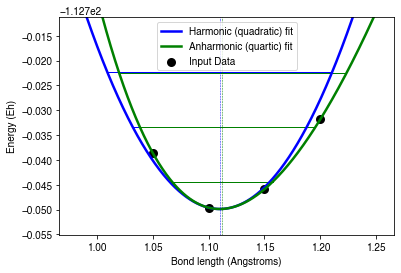

In [12]:
# Below, we have our psi4 function that will compute, print and plot
# our spectroscopic constants
data = psi4.diatomic.anharmonicity(rvals, energies, plot_fit=".")
print(data)

We also have this information in a python object called 'data', which we can access later if we want. 

## B. Spectroscopic constants of CO

In the remainder of this notebook, you will use the previous code along with equations given last week to compute spectroscopic constants for CO, HCl, and DCl. The HCl and DCl data will be used in your written reports, and I will have a few questions regarding the CO data, though this does not go into your written reports.

 1. Using the cell below (use the same cell, just overwrite the output), perform a geometry optimization of the CO molecule using SCF, MP2, CCSD, and CCSD(T) with both cc-pVDZ and cc-pVTZ basis sets. There are a total of eight geometry optimizations. For each computation, record the optimized bond length (in angstrom) in the table below.

In [15]:
### run your calculations here



|Method|cc-pVDZ|cc-pVTZ|
|-      |-|-|
|SCF    | | |
|MP2    | | |
|CCSD   | | |
|CCSD(T)| | |

 2. Using the same set of four methods, use the cell below to run the anharmonicity analysis using a 7 point fit. Be sure to center your seven points around the appropriate $r_e$. Tabulate the constants from each method in the table that follows. You only need to do this for the cc-pVTZ basis set. In the final column, input experimental data for CO by looking up values from the NIST webpage.

In [ ]:
### run your calculations here




|Constant|SCF|MP2|CCSD|CCSD(T)| Exp.|
|-            |-|-|-|-|-|
|$r_e$        | | | | | |
|$\nu_e$      | | | | | |
|$\nu_e\chi_e$| | | | | |
|$k$          | | | | | |
|$B_e$        | | | | | |
|$\alpha_e$   | | | | | |
|$D_e$        | | | | | |

 3. In the cell below, elaborate on your findings above. Which methods are the most accurate with respect to experiment? Which constants are relatively insensitive to the level of theory?

## C. Spectroscopic constants of HCl

We will now repeat the above exercise for the HCl molecule.

 1. Complete the table below with your experimentally determined values from last week. 

|Constant     |Exp.|
|-            |-|
|$r_e$        | |
|$\nu_e$      | |
|$\nu_e\chi_e$| |
|$k$          | |
|$B_e$        | | 
|$\alpha_e$   | | 
|$D_e$        | | 

 2. Using the cell below (use the same cell, just overwrite the output), perform a geometry optimization of the HCl molecule using SCF, MP2, CCSD, and CCSD(T) with both cc-pVDZ and cc-pVTZ basis sets. There are a total of eight geometry optimizations. For each computation, record the optimized bond length (in angstrom) in the table below.

In [ ]:
## Run your calculations here



|Method|cc-pVDZ|cc-pVTZ|
|-      |-|-|
|SCF    | | |
|MP2    | | |
|CCSD   | | |
|CCSD(T)| | |

 3. Using the same set of four methods, use the cell below to run the anharmonicity analysis using a 7 point fit. Be sure to center your seven points around the appropriate $r_e$. Tabulate the constants from each method in the table that follows. You only need to do this for the cc-pVTZ basis set. In the final column, input experimental data for HCl by looking up values from the NIST webpage.

In [ ]:
### Run your calculations here



|Constant|SCF|MP2|CCSD|CCSD(T)| Exp. (NIST) |
|-            |-|-|-|-|-|
|$r_e$        | | | | | |
|$\nu_e$      | | | | | |
|$\nu_e\chi_e$| | | | | |
|$k$          | | | | | |
|$B_e$        | | | | | |
|$\alpha_e$   | | | | | |
|$D_e$        | | | | | |

 4. Again, discuss how your theoretical results compare to your experimental ones. Is the behavior basically the same as seen with CO, or are there differences?

5. Based on your results, is anharmonicity a more significant factor for HF or CO? Explain your reasoning.

 6. Compare the force constants for HCl and CO. For which molecule is $k$ larger, why might this be? Do your results agree with the typical bond orders expected for HF and CO? 

 7. Looking at the plots output from psi4, do you think it is more important to compute anharmonicity corrections for ground state calculations or excited state energies? Explain your answer.

## C. Spectroscopic constants of DCl

Lastly, we will compute the spectroscopic constants for DCl. However, in electronic structure computations, only the nuclear charges and number of electrons enter the computation to generate a PES. Therefore, the PES for HCl and DCl will be identical. So, there is no need to re-determine the optimized bond lengths; the ones from HCl can be used.

1. Using the $r_e$ values from the HCl computations, run the anharm 